<a href="https://colab.research.google.com/github/Mubiala/VISION-PAR-ORDINATEUR/blob/main/diffusion_medical_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# PROJET : Génération d'images synthétiques par modèles de diffusion pour
#          l'augmentation de données médicales
# Sujet 14 - Vision par Ordinateur - M2 IA_SD - UNIKIN
# Groupe : LUVETU DIALUNGANA Salomon, WABA MPWO Exauce, MUBIALA KIESE Samuel
# ==============================================================================

In [1]:
!pip install -q diffusers accelerate kaggle

In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'Entrez votre clé ici'  # à renseigner par l'utilisateur

!pip install -q --upgrade kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d /content/data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 16.3 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:19<00:00, 129MB/s]



In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
from diffusers import UNet2DModel, DDPMScheduler
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

IMG_SIZE = 64          # résolution réduite pour un entraînement rapide sur Colab
BATCH_SIZE = 32
DATA_ROOT = "/content/data/chest_xray"

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device utilisé : cuda


Nombre d'images PNEUMONIA pour l'entraînement du modèle de diffusion : 3875


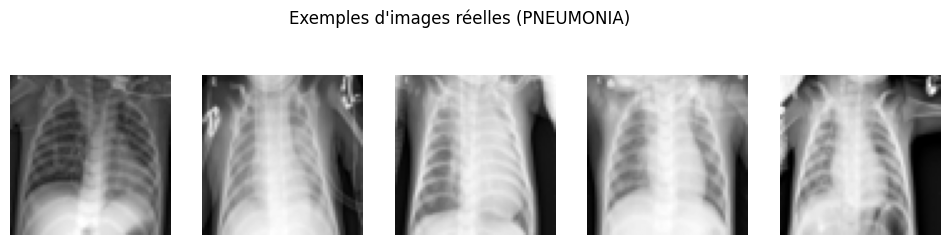

In [5]:
class ChestXrayDataset(Dataset):
    """Charge les images d'une seule classe (utile pour entraîner un modèle
    de diffusion spécifique à la classe minoritaire ou à chaque classe)."""
    def __init__(self, root_dir, split, label, img_size=IMG_SIZE):
        pattern = os.path.join(root_dir, split, label, "*.jpeg")
        self.paths = glob.glob(pattern)
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])  # met les pixels dans [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")
        return self.transform(img)

# On entraîne le modèle de diffusion sur la classe PNEUMONIA
# (c'est souvent la classe qu'on veut renforcer ou étudier ; vous pouvez
# aussi faire NORMAL, ou entraîner un modèle conditionnel pour les deux)
train_dataset_pneumonia = ChestXrayDataset(DATA_ROOT, "train", "PNEUMONIA")
train_loader_diffusion = DataLoader(train_dataset_pneumonia, batch_size=BATCH_SIZE,
                                     shuffle=True, num_workers=2, drop_last=True)

print(f"Nombre d'images PNEUMONIA pour l'entraînement du modèle de diffusion : {len(train_dataset_pneumonia)}")

# Aperçu de quelques images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    img = train_dataset_pneumonia[i][0]
    ax.imshow(img, cmap="gray")
    ax.axis("off")
plt.suptitle("Exemples d'images réelles (PNEUMONIA)")
plt.show()

In [6]:
model = UNet2DModel(
    sample_size=IMG_SIZE,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
).to(device)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print("Nombre de paramètres du modèle :", sum(p.numel() for p in model.parameters()))

Nombre de paramètres du modèle : 17215617


Epoch 1/40:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 1 - loss moyenne : 0.0172


Epoch 2/40:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 2 - loss moyenne : 0.0181


Epoch 3/40:   0%|          | 0/121 [00:00<?, ?it/s]

...

Epoch 38 - loss moyenne : 0.0165


Epoch 39/40:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 39 - loss moyenne : 0.0175


Epoch 40/40:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 40 - loss moyenne : 0.0162


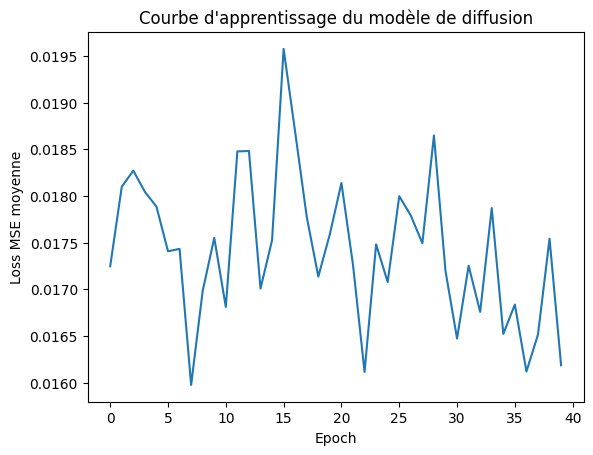

In [10]:
# Avec un GPU T4 (Colab gratuit), ~30-50 epochs sur ce dataset restreint
# prennent environ 30-60 minutes. Adaptez NUM_EPOCHS selon le temps disponible.
NUM_EPOCHS = 40

losses = []
model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    progress = tqdm(train_loader_diffusion, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in progress:
        clean_images = batch.to(device)
        noise = torch.randn_like(clean_images)
        bs = clean_images.shape[0]

        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                   (bs,), device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(train_loader_diffusion)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1} - loss moyenne : {avg_loss:.4f}")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss MSE moyenne")
plt.title("Courbe d'apprentissage du modèle de diffusion")
plt.show()

# Sauvegarde du modèle entraîné (utile pour votre rapport / réutilisation)
torch.save(model.state_dict(), "/content/diffusion_model_pneumonia.pt")

Génération (denoising):   0%|          | 0/1000 [00:00<?, ?it/s]

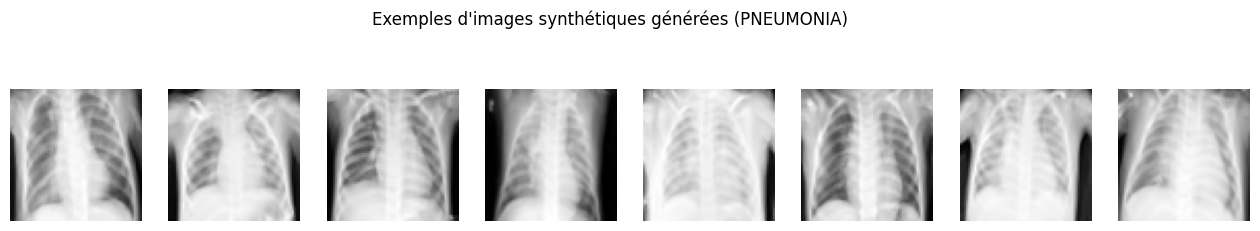

Génération (denoising):   0%|          | 0/1000 [00:00<?, ?it/s]

Génération (denoising):   0%|          | 0/1000 [00:00<?, ?it/s]

Génération (denoising):   0%|          | 0/1000 [00:00<?, ?it/s]

Génération (denoising):   0%|          | 0/1000 [00:00<?, ?it/s]

Génération (denoising):   0%|          | 0/1000 [00:00<?, ?it/s]

Génération (denoising):   0%|          | 0/1000 [00:00<?, ?it/s]

Génération (denoising):   0%|          | 0/1000 [00:00<?, ?it/s]

200 images synthétiques sauvegardées dans /content/synthetic_pneumonia


In [11]:
@torch.no_grad()
def generate_images(model, scheduler, num_images, img_size=IMG_SIZE):
    model.eval()
    images = torch.randn(num_images, 1, img_size, img_size, device=device)
    for t in tqdm(scheduler.timesteps, desc="Génération (denoising)"):
        noise_pred = model(images, t, return_dict=False)[0]
        images = scheduler.step(noise_pred, t, images).prev_sample
    images = (images.clamp(-1, 1) + 1) / 2  # retour dans [0, 1]
    return images.cpu()

NUM_SYNTHETIC = 200  # nombre d'images synthétiques à générer
synthetic_images = generate_images(model, noise_scheduler, num_images=8)  # aperçu rapide

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(synthetic_images[i][0], cmap="gray")
    ax.axis("off")
plt.suptitle("Exemples d'images synthétiques générées (PNEUMONIA)")
plt.show()

# Génération du lot complet à sauvegarder pour l'augmentation
os.makedirs("/content/synthetic_pneumonia", exist_ok=True)
generated_count = 0
BATCH_GEN = 32
while generated_count < NUM_SYNTHETIC:
    n = min(BATCH_GEN, NUM_SYNTHETIC - generated_count)
    batch_imgs = generate_images(model, noise_scheduler, num_images=n)
    for i in range(n):
        arr = (batch_imgs[i][0].numpy() * 255).astype(np.uint8)
        Image.fromarray(arr).save(f"/content/synthetic_pneumonia/synth_{generated_count+i:04d}.png")
    generated_count += n
print(f"{generated_count} images synthétiques sauvegardées dans /content/synthetic_pneumonia")

In [14]:
class LabeledXrayDataset(Dataset):
    """Dataset pour la classification binaire NORMAL / PNEUMONIA.
    extra_synthetic_dir : dossier optionnel d'images synthétiques PNEUMONIA
    à ajouter au jeu d'entraînement."""
    def __init__(self, root_dir, split, img_size=IMG_SIZE, extra_synthetic_dir=None):
        self.samples = []
        for label, cls_idx in [("NORMAL", 0), ("PNEUMONIA", 1)]:
            for p in glob.glob(os.path.join(root_dir, split, label, "*.jpeg")):
                self.samples.append((p, cls_idx))

        if extra_synthetic_dir is not None:
            for p in glob.glob(os.path.join(extra_synthetic_dir, "*.png")):
                self.samples.append((p, 1))  # les synthétiques sont classe PNEUMONIA

        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("L")
        return self.transform(img), label

# Jeu A : baseline (données réelles uniquement)
train_baseline = LabeledXrayDataset(DATA_ROOT, "train")
# Jeu B : augmenté (données réelles + synthétiques)
train_augmented = LabeledXrayDataset(DATA_ROOT, "train",
                                      extra_synthetic_dir="/content/synthetic_pneumonia")
test_dataset = LabeledXrayDataset(DATA_ROOT, "test")

print("Taille jeu baseline :", len(train_baseline))
print("Taille jeu augmenté :", len(train_augmented))
print("Taille jeu de test :", len(test_dataset))

Taille jeu baseline : 5216
Taille jeu augmenté : 5416
Taille jeu de test : 624


In [15]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64->32
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32->16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16->8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def train_classifier(train_ds, num_epochs=8, lr=1e-3):
    loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
    clf = SimpleCNN().to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=lr)
    clf.train()
    for epoch in range(num_epochs):
        total_loss, correct, total = 0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = clf(x)
            loss = F.cross_entropy(out, y)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        print(f"  Epoch {epoch+1}/{num_epochs} - loss: {total_loss/len(loader):.4f} - acc: {correct/total:.4f}")
    return clf

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

@torch.no_grad()
def evaluate(clf, test_ds):
    loader = DataLoader(test_ds, batch_size=32, shuffle=False)
    clf.eval()
    all_preds, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        out = clf(x)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())
    return {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds),
        "recall": recall_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
        "confusion_matrix": confusion_matrix(all_labels, all_preds)
    }

print("=== Scénario A : entraînement SANS augmentation ===")
clf_baseline = train_classifier(train_baseline)
results_baseline = evaluate(clf_baseline, test_dataset)
print(results_baseline)

print("\n=== Scénario B : entraînement AVEC augmentation par diffusion ===")
clf_augmented = train_classifier(train_augmented)
results_augmented = evaluate(clf_augmented, test_dataset)
print(results_augmented)

=== Scénario A : entraînement SANS augmentation ===
  Epoch 1/8 - loss: 0.2616 - acc: 0.8911
  Epoch 2/8 - loss: 0.1303 - acc: 0.9503
  Epoch 3/8 - loss: 0.0998 - acc: 0.9607
  Epoch 4/8 - loss: 0.0830 - acc: 0.9663
  Epoch 5/8 - loss: 0.0741 - acc: 0.9722
  Epoch 6/8 - loss: 0.0651 - acc: 0.9751
  Epoch 7/8 - loss: 0.0558 - acc: 0.9799
  Epoch 8/8 - loss: 0.0515 - acc: 0.9799
{'accuracy': 0.7980769230769231, 'precision': 0.764, 'recall': 0.9794871794871794, 'f1': 0.8584269662921349, 'confusion_matrix': array([[116, 118],
       [  8, 382]])}

=== Scénario B : entraînement AVEC augmentation par diffusion ===
  Epoch 1/8 - loss: 0.2373 - acc: 0.8994
  Epoch 2/8 - loss: 0.1213 - acc: 0.9533
  Epoch 3/8 - loss: 0.0900 - acc: 0.9664
  Epoch 4/8 - loss: 0.0818 - acc: 0.9684
  Epoch 5/8 - loss: 0.0672 - acc: 0.9743
  Epoch 6/8 - loss: 0.0594 - acc: 0.9795
  Epoch 7/8 - loss: 0.0527 - acc: 0.9817
  Epoch 8/8 - loss: 0.0471 - acc: 0.9819
{'accuracy': 0.7676282051282052, 'precision': 0.73156899

                               accuracy  precision    recall        f1
Sans augmentation              0.798077   0.764000  0.979487  0.858427
Avec augmentation (diffusion)  0.767628   0.731569  0.992308  0.842220


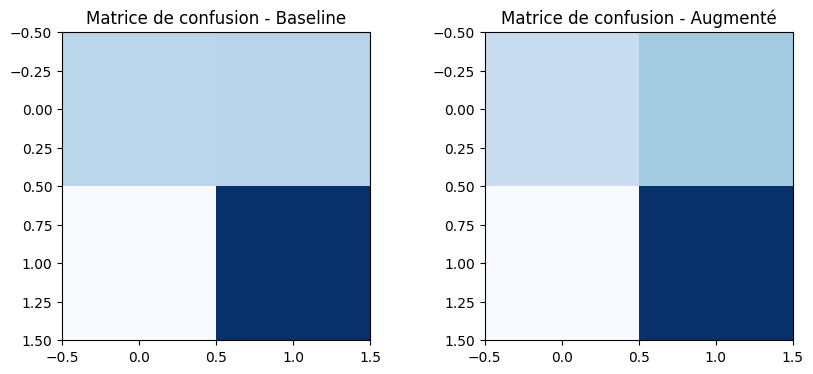

In [17]:
import pandas as pd
comparison = pd.DataFrame({
    "Sans augmentation": {k: v for k, v in results_baseline.items() if k != "confusion_matrix"},
    "Avec augmentation (diffusion)": {k: v for k, v in results_augmented.items() if k != "confusion_matrix"},
}).T
print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(results_baseline["confusion_matrix"], cmap="Blues")
axes[0].set_title("Matrice de confusion - Baseline")
axes[1].imshow(results_augmented["confusion_matrix"], cmap="Blues")
axes[1].set_title("Matrice de confusion - Augmenté")
plt.show()

# ==============================================================================
# ==============================================================================